In [4]:
import pandas as pd 
import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt

In [14]:
df=pd.read_csv("titanic.csv", sep="\t" )
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
151,152,1,1,"Pears, Mrs. Thomas (Edith Wearne)",female,22.0,1,0,113776,66.6000,C2,S
152,153,0,3,"Meo, Mr. Alfonzo",male,55.5,0,0,A.5. 11206,8.0500,NaN,S
153,154,0,3,"van Billiard, Mr. Austin Blyler",male,40.5,0,2,A/5. 851,14.5000,NaN,S
154,155,0,3,"Olsen, Mr. Ole Martin",male,NaN,0,0,Fa 265302,7.3125,NaN,S


In [19]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             30
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          125
Embarked         1
dtype: int64

In [22]:
df=df.drop("Cabin" ,axis=1)

In [23]:
df.isnull().sum()

PassengerId     0
Survived        0
Pclass          0
Name            0
Sex             0
Age            30
SibSp           0
Parch           0
Ticket          0
Fare            0
Embarked        1
dtype: int64

In [26]:
df["Age"]=df["Age"].fillna(df["Age"].median())

In [27]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       1
dtype: int64

In [33]:
df[df["Embarked"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,NaN


In [36]:
df=df.dropna()

In [37]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [55]:
result=df.groupby("Sex")["Survived"].sum()

In [56]:
result1=df.groupby("Sex").size()

In [60]:
print("chech male or femel sevvible in persentage fome")
female=result["female"]/result1["female"]*100
print("female: " ,female,"%")

male=result["male"]/result1["male"]*100
print("male:",male,"%")


chech male or femel sevvible in persentage fome
female:  70.9090909090909 %
male: 14.000000000000002 %


In [62]:
df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
151,152,1,1,"Pears, Mrs. Thomas (Edith Wearne)",female,22.0,1,0,113776,66.6000,S
152,153,0,3,"Meo, Mr. Alfonzo",male,55.5,0,0,A.5. 11206,8.0500,S
153,154,0,3,"van Billiard, Mr. Austin Blyler",male,40.5,0,2,A/5. 851,14.5000,S
154,155,0,3,"Olsen, Mr. Ole Martin",male,26.0,0,0,Fa 265302,7.3125,S


In [64]:
df.groupby("Pclass")["Survived"].sum()

Pclass
1    11
2    14
3    28
Name: Survived, dtype: int64

In [66]:
df.groupby("Survived").size()

Survived
0    102
1     53
dtype: int64

In [68]:
bins=[0,12,18,35,60,100]
labels=["child","teenager","young","adult","senior"]
df["aggroup"]=pd.cut(df["Age"], bins=bins,labels=labels)

In [82]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,aggroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,young
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,young
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,young
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,young
...,...,...,...,...,...,...,...,...,...,...,...,...
151,152,1,1,"Pears, Mrs. Thomas (Edith Wearne)",female,22.0,1,0,113776,66.6000,S,young
152,153,0,3,"Meo, Mr. Alfonzo",male,55.5,0,0,A.5. 11206,8.0500,S,adult
153,154,0,3,"van Billiard, Mr. Austin Blyler",male,40.5,0,2,A/5. 851,14.5000,S,adult
154,155,0,3,"Olsen, Mr. Ole Martin",male,26.0,0,0,Fa 265302,7.3125,S,young


In [73]:
df.groupby("aggroup")["Survived"].mean()*100

C:\Users\akash\AppData\Local\Temp\ipykernel_34248\3000241172.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("aggroup")["Survived"].mean()*100


aggroup
child       38.461538
teenager    35.714286
young       38.775510
adult       19.230769
senior       0.000000
Name: Survived, dtype: float64

# Visualize using Seaborn / Matplotlib:
o Bar chart of survival by gender.
o Bar chart of survival by class.
o Histogram of passenger ages.


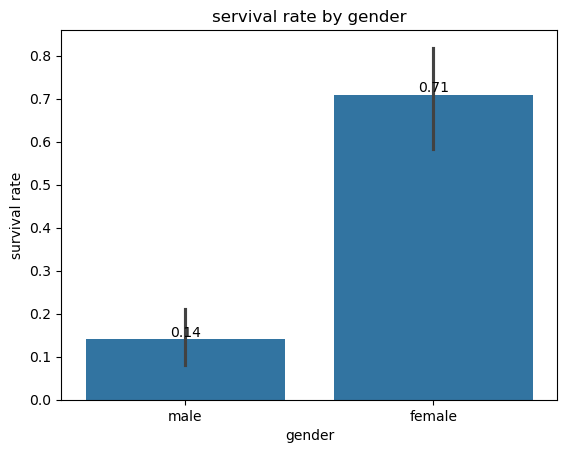

In [80]:
ax=sns.barplot(data=df,x="Sex",y="Survived")
plt.title("servival rate by gender")
plt.xlabel("gender")
plt.ylabel("survival rate")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")
plt.show()

In [77]:
survival_rate = df.groupby("Sex")["Survived"].mean() * 100

print(survival_rate)

Sex
female    70.909091
male      14.000000
Name: Survived, dtype: float64


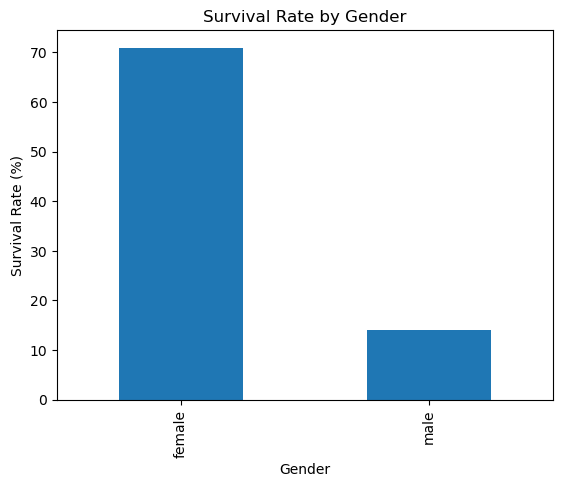

In [78]:
survival_rate.plot(kind="bar")

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")
plt.show()

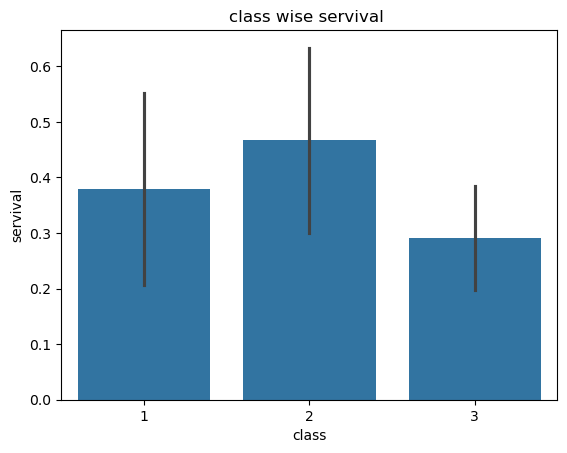

In [83]:
ax =sns.barplot(data=df,x="Pclass",y="Survived")
plt.title("class wise servival ")
plt.xlabel("class")
plt.ylabel("servival")
plt.show()
          

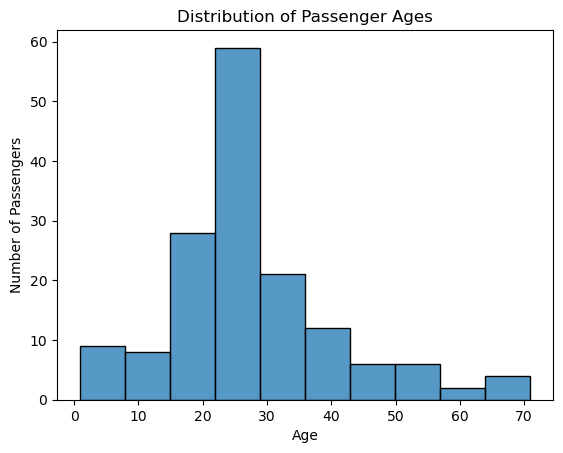

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x="Age", bins=10)

plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

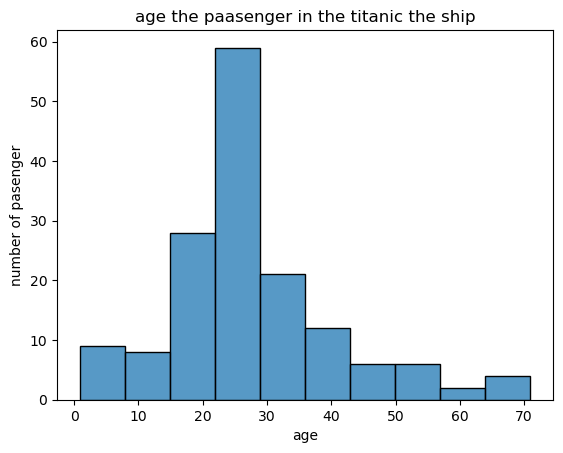

In [89]:
sns.histplot(data=df,x="Age",bins=10)
plt.title("age the paasenger in the titanic the ship")
plt.xlabel("age")
plt.ylabel("number of pasenger")
plt.show()